In [3]:
import nibabel as nib
import numpy as np
import pandas as pd
import os

In [4]:
# ============================================================
# Configure data
# ============================================================

dataset_path     = r"C:\Users\tl\Documents\MnM2\MnM2\dataset"
dataset_info_path= r"C:\Users\tl\Documents\MnM2\MnM2\dataset_information.csv"
output_csv       = r"C:\Users\tl\Documents\MnM2\MnM2\annotations.csv"
removed_csv      = r"C:\Users\tl\Documents\MnM2\MnM2\removed_patients.csv"

Unique labels in GT file: [0. 1. 2. 3.]


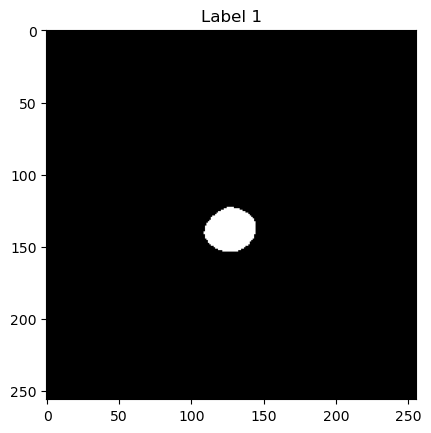

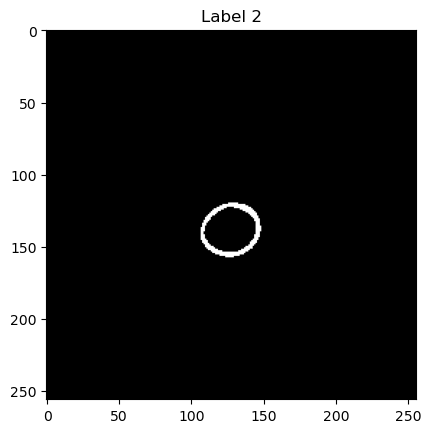

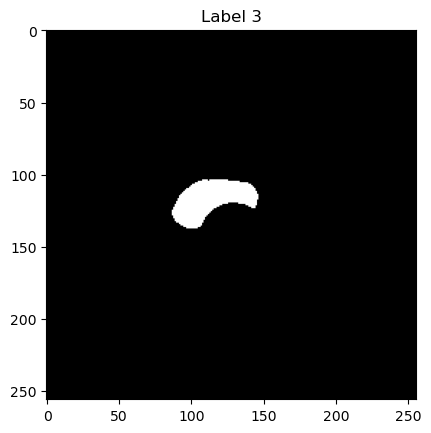

In [5]:
# ============================================================
# Identify label values
# ============================================================

# Load one example GT file to identify label values
example_gt = os.path.join(dataset_path, "001", "001_SA_ED_gt.nii.gz")
img  = nib.load(example_gt)
data = img.get_fdata()
print("Unique labels in GT file:", np.unique(data))

# Visualize each label to confirm which is LV
import matplotlib.pyplot as plt
slice_2d = data[:, :, 3]
for label in [1, 2, 3]:
    plt.imshow(slice_2d == label, cmap='gray')
    plt.title(f"Label {label}")
    plt.show()


In [6]:

# ============================================================
# helper function for getting left ventricle area (i.e. label 1 area)
# ============================================================

def get_lv_areas(gt_path, lv_label):
    """
    Loads a GT NIfTI file.
    Returns LV area (mm²) per slice and Z spacing (mm).
    """
    img  = nib.load(gt_path)
    data = img.get_fdata()
    zooms = img.header.get_zooms()
    pixel_area_mm2 = zooms[0] * zooms[1]
    z_spacing_mm   = zooms[2]

    if data.ndim == 2:
        data = data[:, :, np.newaxis]

    areas = []
    for z in range(data.shape[2]):
        lv_pixel_count = np.sum(data[:, :, z] == lv_label)
        areas.append(lv_pixel_count * pixel_area_mm2)

    return areas, z_spacing_mm

In [7]:
# ============================================================
# Build .csv file with LV areas and relevant annotations from dataset_information.csv
# ============================================================
lv_label         = 1

# Load dataset info
info = pd.read_csv(dataset_info_path, low_memory=False)
info = info.dropna(subset=['SUBJECT_CODE'])
info['patient_id'] = info['SUBJECT_CODE'].astype(float).astype(int)
info = info.set_index('patient_id')

rows = []

patient_folders = sorted([
    f for f in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, f))
])

for patient_id_str in patient_folders:
    patient_path = os.path.join(dataset_path, patient_id_str)
    patient_id   = int(patient_id_str)
    print(f"Processing patient {patient_id_str}...")

    # Get metadata
    if patient_id in info.index:
        disease = info.loc[patient_id, 'DISEASE']
        vendor  = info.loc[patient_id, 'VENDOR']
        scanner = info.loc[patient_id, 'SCANNER']
        field   = info.loc[patient_id, 'FIELD']
    else:
        disease = vendor = scanner = field = None

    # --- SAX ---
    sax_ed_file = os.path.join(patient_path, f"{patient_id_str}_SA_ED_gt.nii.gz")
    sax_es_file = os.path.join(patient_path, f"{patient_id_str}_SA_ES_gt.nii.gz")

    if os.path.exists(sax_ed_file) and os.path.exists(sax_es_file):
        sax_ed_areas, z_spacing = get_lv_areas(sax_ed_file, lv_label)
        sax_es_areas, _         = get_lv_areas(sax_es_file, lv_label)

        for z_idx in range(len(sax_ed_areas)):
            rows.append({
                "patient_id":     patient_id,
                "disease":        disease,
                "vendor":         vendor,
                "scanner":        scanner,
                "field":          field,
                "view":           "SAX",
                "z_slice":        z_idx,
                "z_spacing_mm":   z_spacing,
                "lv_area_ED_mm2": sax_ed_areas[z_idx],
                "lv_area_ES_mm2": sax_es_areas[z_idx]
            })

    # --- LAX ---
    lax_ed_file = os.path.join(patient_path, f"{patient_id_str}_LA_ED_gt.nii.gz")
    lax_es_file = os.path.join(patient_path, f"{patient_id_str}_LA_ES_gt.nii.gz")

    if os.path.exists(lax_ed_file) and os.path.exists(lax_es_file):
        lax_ed_areas, lax_spacing = get_lv_areas(lax_ed_file, lv_label)
        lax_es_areas, _           = get_lv_areas(lax_es_file, lv_label)

        rows.append({
            "patient_id":     patient_id,
            "disease":        disease,
            "vendor":         vendor,
            "scanner":        scanner,
            "field":          field,
            "view":           "LAX",
            "z_slice":        0,
            "z_spacing_mm":   lax_spacing,
            "lv_area_ED_mm2": lax_ed_areas[0],
            "lv_area_ES_mm2": lax_es_areas[0]
        })

df = pd.DataFrame(rows)
df.to_csv(output_csv, index=False)
print(f"\nAnnotations saved: {output_csv} — {len(df)} rows, {df['patient_id'].nunique()} patients")


Processing patient 001...
Processing patient 002...
Processing patient 003...
Processing patient 004...
Processing patient 005...
Processing patient 006...
Processing patient 007...
Processing patient 008...
Processing patient 009...
Processing patient 010...
Processing patient 011...
Processing patient 012...
Processing patient 013...
Processing patient 014...
Processing patient 015...
Processing patient 016...
Processing patient 017...
Processing patient 018...
Processing patient 019...
Processing patient 020...
Processing patient 021...
Processing patient 022...
Processing patient 023...
Processing patient 024...
Processing patient 025...
Processing patient 026...
Processing patient 027...
Processing patient 028...
Processing patient 029...
Processing patient 030...
Processing patient 031...
Processing patient 032...
Processing patient 033...
Processing patient 034...
Processing patient 035...
Processing patient 036...
Processing patient 037...
Processing patient 038...
Processing p


=== SLICE COUNT DISTRIBUTION ===
z_slice
6       3
7       3
8       5
9      18
10    107
11     60
12    100
13     34
14     19
15      5
16      3
17      2
28      1

=== Z SPACING DISTRIBUTION (mm) ===
z_spacing_mm
5.000000       1
5.200000       1
8.000000       4
8.700000       1
8.800000       4
8.900000       1
9.100000       1
9.500000       2
9.600000     127
9.700000       1
10.000000    206
10.300000      1
10.400000      1
10.500000      1
10.600000      2
10.700000      1
11.300000      1
17.600000      3
19.200001      1


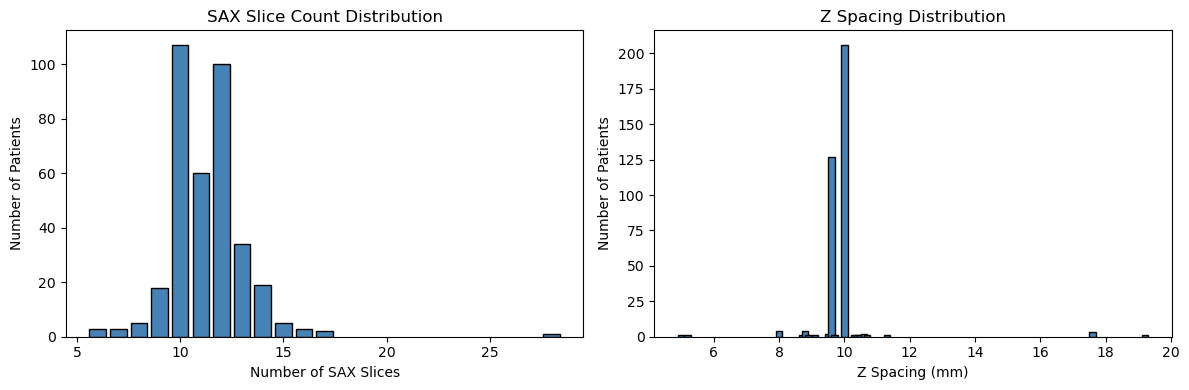

In [13]:
# ============================================================
# Analyze distribution of dataset to identify outliers
# ============================================================
sax = df[df['view'] == 'SAX']
slice_counts = sax.groupby('patient_id')['z_slice'].count()
spacing = sax.groupby('patient_id')['z_spacing_mm'].first().round(1)

print("\n=== SLICE COUNT DISTRIBUTION ===")
print(slice_counts.value_counts().sort_index().to_string())
print("\n=== Z SPACING DISTRIBUTION (mm) ===")
print(spacing.value_counts().sort_index().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Slice count histogram
axes[0].bar(slice_counts.value_counts().sort_index().index,
            slice_counts.value_counts().sort_index().values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of SAX Slices')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('SAX Slice Count Distribution')

# Z spacing histogram
axes[1].bar(spacing.value_counts().sort_index().index,
            spacing.value_counts().sort_index().values, color='steelblue', edgecolor='black', width=0.2)
axes[1].set_xlabel('Z Spacing (mm)')
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Z Spacing Distribution')

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Apply thresholds and remove patient outliers
# Keep patients with 9-14 slices in SAX Z-stack
# Keep patients with slice gaps of 8-11.3 mm
# ============================================================

MIN_SLICES       = 9
MAX_SLICES       = 14
MIN_SPACING      = 7.5
MAX_SPACING      = 11.5

removed_rows = []
kept_ids     = []

for patient_id, group in sax.groupby('patient_id'):
    num_slices = group['z_slice'].count()
    z_spacing  = group['z_spacing_mm'].iloc[0]

    if num_slices < MIN_SLICES or num_slices > MAX_SLICES:
        removed_rows.append({
            "patient_id": patient_id,
            "reason": f"{num_slices} SAX slices (threshold: {MIN_SLICES}-{MAX_SLICES})"
        })
    elif z_spacing < MIN_SPACING or z_spacing > MAX_SPACING:
        removed_rows.append({
            "patient_id": patient_id,
            "reason": f"{z_spacing:.1f} mm Z spacing (threshold: {MIN_SPACING}-{MAX_SPACING} mm)"
        })
    else:
        kept_ids.append(patient_id)

# Filter annotations to kept patients only
df_filtered = df[df['patient_id'].isin(kept_ids)]
df_filtered.to_csv(output_csv, index=False)

# Save removed patients
removed_df = pd.DataFrame(removed_rows)
removed_df.to_csv(removed_csv, index=False)

print(f"\nRemoved {len(removed_rows)} patients:")
print(removed_df.to_string(index=False))
print(f"\nFinal dataset: {df_filtered['patient_id'].nunique()} patients, {len(df_filtered)} rows")
print(f"Removed patients saved: {removed_csv}")


Removed 23 patients:
 patient_id                                    reason
         29            8 SAX slices (threshold: 9-14)
         43           16 SAX slices (threshold: 9-14)
         48           16 SAX slices (threshold: 9-14)
         95            6 SAX slices (threshold: 9-14)
         99            8 SAX slices (threshold: 9-14)
        104           15 SAX slices (threshold: 9-14)
        108           16 SAX slices (threshold: 9-14)
        133            7 SAX slices (threshold: 9-14)
        142           17 SAX slices (threshold: 9-14)
        145           15 SAX slices (threshold: 9-14)
        159            8 SAX slices (threshold: 9-14)
        160            7 SAX slices (threshold: 9-14)
        194           15 SAX slices (threshold: 9-14)
        199            6 SAX slices (threshold: 9-14)
        260            8 SAX slices (threshold: 9-14)
        267            8 SAX slices (threshold: 9-14)
        283            6 SAX slices (threshold: 9-14)
      